# Avaliação Comparativa — M2 Center Crop vs Zero Padding
**Projeto Integrador SENAI FATESG 2025/2026**  
Comparativo completo + exemplos de uso | ROC | PR Curve | DeLong | Grad-CAM

## SEÇÃO 0 — Setup

In [1]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy scipy
!pip install -q grad-cam  # para tf-keras-vis alternativo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, classification_report,
    confusion_matrix, brier_score_loss
)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE   = '/content/drive/MyDrive'
CROP_DIR = f'{BASE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore'
PAD_DIR  = f'{BASE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Padding_UIgnore'

CROP_MODEL = f'{CROP_DIR}/m2_crop_final.keras'
PAD_MODEL  = f'{PAD_DIR}/m2_padding_final.keras'

CHEX_CROP_DIR = f'{BASE}/datasets_pi_2026/estruturacao/Stanford_Cropping'
CHEX_PAD_DIR  = f'{BASE}/datasets_pi_2026/estruturacao/Stanford_Zero_Padding'
VALID_CSV_CROP = f'{CHEX_CROP_DIR}/chex_crop_valid.csv'
VALID_CSV_PAD  = f'{CHEX_PAD_DIR}/chex_pad_valid.csv'

LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)
IMG_SIZE = 512

OUT_DIR = f'{BASE}/datasets_pi_2026/avaliacao_comparativa'
os.makedirs(OUT_DIR, exist_ok=True)

print('Verificando arquivos:')
for path, name in [(CROP_MODEL,'Crop model'),(PAD_MODEL,'Pad model'),
                   (VALID_CSV_CROP,'Valid CSV Crop'),(VALID_CSV_PAD,'Valid CSV Pad')]:
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name}')

Verificando arquivos:
  ✅ Crop model
  ✅ Pad model
  ✅ Valid CSV Crop
  ✅ Valid CSV Pad


## SEÇÃO 1 — Classes Customizadas e Carregamento dos Modelos

In [4]:
class FocalLossUIgnore(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma; self.alpha = alpha
        self.label_weights = (tf.constant(label_weights, dtype=tf.float32)
                              if label_weights is not None else tf.ones(N_LABELS))
    def call(self, y_true, y_pred):
        labels = y_true[:, :N_LABELS]; mask = y_true[:, N_LABELS:]
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        bce    = -(labels*tf.math.log(y_pred)+(1-labels)*tf.math.log(1-y_pred))
        p_t    = labels*y_pred+(1-labels)*(1-y_pred)
        alpha_t= labels*self.alpha+(1-labels)*(1-self.alpha)
        focal  = alpha_t*tf.pow(1-p_t,self.gamma)*bce*self.label_weights
        return tf.reduce_sum(focal*mask)/(tf.reduce_sum(mask)+1e-7)
    def get_config(self):
        c = super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,
                  'label_weights':self.label_weights.numpy().tolist()})
        return c

class MacroAUROC(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.aucs = [tf.keras.metrics.AUC(curve='ROC',name=f'auc_{i}') for i in range(n_labels)]
    def update_state(self, y_true, y_pred, sample_weight=None):
        labels = y_true[:,:self.n_labels]
        for i,auc in enumerate(self.aucs): auc.update_state(labels[:,i],y_pred[:,i])
    def result(self): return tf.reduce_mean([a.result() for a in self.aucs])
    def reset_state(self):
        for a in self.aucs: a.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels']=self.n_labels; return c

class MaskedBinaryAccuracy(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.acc = tf.keras.metrics.BinaryAccuracy()
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.acc.update_state(y_true[:,:self.n_labels], y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels']=self.n_labels; return c

CUSTOM = {'FocalLossUIgnore':FocalLossUIgnore,
          'MacroAUROC':MacroAUROC,
          'MaskedBinaryAccuracy':MaskedBinaryAccuracy}

print('Carregando modelos...')
model_crop = tf.keras.models.load_model(CROP_MODEL, custom_objects=CUSTOM, compile=False)
model_pad  = tf.keras.models.load_model(PAD_MODEL,  custom_objects=CUSTOM, compile=False)
print(f'Crop : {model_crop.count_params():,} parâmetros')
print(f'Pad  : {model_pad.count_params():,} parâmetros')

Carregando modelos...
Crop : 22,045,486 parâmetros
Pad  : 22,045,486 parâmetros


## SEÇÃO 2 — Dataset de Validação

In [5]:
df_valid_crop = pd.read_csv(VALID_CSV_CROP)
df_valid_pad  = pd.read_csv(VALID_CSV_PAD)
print(f'Valid Crop : {len(df_valid_crop)} imagens')
print(f'Valid Pad  : {len(df_valid_pad)} imagens')

# y_true é idêntico para Crop e Pad (mesmas imagens, só preprocessing diferente)
y_true = df_valid_crop[LABELS].values.astype(np.float32)
print(f'y_true shape: {y_true.shape}')
print('\nPositivos por label:')
for lbl in LABELS:
    n = int(y_true[:,LABELS.index(lbl)].sum())
    print(f'  {lbl:<20}: {n}')

Valid Crop : 159 imagens
Valid Pad  : 159 imagens
y_true shape: (159, 6)

Positivos por label:
  atelectasis         : 75
  cardiomegaly        : 66
  pleural_effusion    : 64
  pneumothorax        : 7
  consolidation       : 32
  edema               : 42


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import time
import numpy as np
from PIL import Image as PILImage

def load_image_pil(img_path_bytes):
    """Leitura com PIL — mais resiliente ao Drive que tf.io.read_file."""
    img_path = img_path_bytes.numpy().decode()
    for attempt in range(5):
        try:
            img = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img, dtype=np.float32) / 255.0
            img = (img - 0.5056) / 0.2520
            img = np.stack([img, img, img], axis=-1)  # grayscale → 3 canais
            return img.astype(np.float32)
        except Exception:
            if attempt < 4:
                time.sleep(2.0)
            else:
                raise

def make_pred_dataset(df, batch_size=32):
    paths = df['img_path'].values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(
        lambda p: tf.py_function(load_image_pil, [p], tf.float32),
        num_parallel_calls=1
    )
    ds = ds.map(lambda x: tf.ensure_shape(x, [IMG_SIZE, IMG_SIZE, 3]))
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print('Criando datasets...')
ds_valid_crop = make_pred_dataset(df_valid_crop)
ds_valid_pad  = make_pred_dataset(df_valid_pad)

print('Predições Crop...')
y_pred_crop = model_crop.predict(ds_valid_crop, verbose=1)

# Pausa entre predições — Drive precisa respirar
print('Aguardando 5s antes do Padding...')
time.sleep(5)

print('Predições Padding...')
y_pred_pad = model_pad.predict(ds_valid_pad, verbose=1)

print(f'Pred Crop shape: {y_pred_crop.shape}')
print(f'Pred Pad  shape: {y_pred_pad.shape}')

Mounted at /content/drive
Criando datasets...
Predições Crop...
5/5 ━━━━━━━━━━━━━━━━━━━━ 440s 13s/step
Aguardando 5s antes do Padding...
Predições Padding...
5/5 ━━━━━━━━━━━━━━━━━━━━ 385s 12s/step
Pred Crop shape: (159, 6)
Pred Pad  shape: (159, 6)


## SEÇÃO 3 — Métricas Completas (AUROC, AUPRC, F1)

In [7]:
def compute_metrics(y_true, y_pred, labels, threshold=0.5):
    """Computa métricas completas por label."""
    results = {}
    for i, lbl in enumerate(labels):
        yt = y_true[:, i]; yp = y_pred[:, i]
        if len(np.unique(yt)) < 2:
            results[lbl] = {'auroc':None,'auprc':None,'f1':None,
                            'sensitivity':None,'specificity':None,'brier':None}
            continue
        yp_bin = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_bin).ravel()
        results[lbl] = {
            'auroc'      : roc_auc_score(yt, yp),
            'auprc'      : average_precision_score(yt, yp),
            'f1'         : f1_score(yt, yp_bin, zero_division=0),
            'sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
            'specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
            'precision'  : tp/(tp+fp) if (tp+fp)>0 else 0,
            'brier'      : brier_score_loss(yt, yp),
        }
    # Macro averages
    valid = [v for v in results.values() if v['auroc'] is not None]
    results['MACRO'] = {k: np.mean([v[k] for v in valid if v[k] is not None])
                        for k in ['auroc','auprc','f1','sensitivity','specificity','brier']}
    return results

metrics_crop = compute_metrics(y_true, y_pred_crop, LABELS)
metrics_pad  = compute_metrics(y_true, y_pred_pad,  LABELS)

# Print comparison table
print(f'\n{"Label":<22} {"AUROC Crop":>10} {"AUROC Pad":>10} {"Δ":>8} {"AUPRC Crop":>11} {"AUPRC Pad":>10}')
print('-'*75)
for lbl in LABELS + ['MACRO']:
    mc = metrics_crop[lbl]; mp = metrics_pad[lbl]
    if mc['auroc'] is None: continue
    delta = mc['auroc'] - mp['auroc']
    winner = '✅C' if delta > 0 else '✅P'
    print(f'{lbl:<22} {mc["auroc"]:>10.4f} {mp["auroc"]:>10.4f} {delta:>+8.4f} {mc["auprc"]:>11.4f} {mp["auprc"]:>10.4f}')

# Save
comparison = {'crop': {k:{m:float(v) for m,v in d.items() if v is not None}
                        for k,d in metrics_crop.items()},
              'pad':  {k:{m:float(v) for m,v in d.items() if v is not None}
                        for k,d in metrics_pad.items()}}
with open(f'{OUT_DIR}/metrics_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print(f'\nMétricas salvas.')


Label                  AUROC Crop  AUROC Pad        Δ  AUPRC Crop  AUPRC Pad
---------------------------------------------------------------------------
atelectasis                0.8103     0.7992  +0.0111      0.7466     0.7399
cardiomegaly               0.8254     0.8196  +0.0057      0.7763     0.7651
pleural_effusion           0.8773     0.8857  -0.0084      0.8438     0.8386
pneumothorax               0.9248     0.8806  +0.0442      0.6081     0.5172
consolidation              0.8932     0.8684  +0.0249      0.5975     0.5818
edema                      0.8948     0.8834  +0.0114      0.7525     0.7213
MACRO                      0.8710     0.8562  +0.0148      0.7208     0.6940

Métricas salvas.


## SEÇÃO 4 — Teste Estatístico DeLong (AUROC)

In [8]:
def delong_roc_variance(ground_truth, predictions):
    """Calcula variância do AUROC via método DeLong."""
    order = np.argsort(-predictions)
    label_1_count = int(ground_truth.sum())
    label_0_count = len(ground_truth) - label_1_count
    ordered_labels = ground_truth[order]
    tp = np.cumsum(ordered_labels)
    fp = np.cumsum(1 - ordered_labels)
    fpr = fp / label_0_count
    tpr = tp / label_1_count
    auc = np.trapz(tpr, fpr)
    # Structural components
    v10 = np.zeros(label_1_count); v01 = np.zeros(label_0_count)
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    for i, pi in enumerate(pos_idx):
        v10[i] = np.mean(predictions[pi] > predictions[neg_idx]) +                  0.5 * np.mean(predictions[pi] == predictions[neg_idx])
    for j, nj in enumerate(neg_idx):
        v01[j] = np.mean(predictions[pos_idx] > predictions[nj]) +                  0.5 * np.mean(predictions[pos_idx] == predictions[nj])
    var = (np.var(v10) / label_1_count + np.var(v01) / label_0_count)
    return auc, var

print('Teste DeLong — comparação de AUROCs Crop vs Padding')
print(f'\n{"Label":<22} {"AUROC Crop":>10} {"AUROC Pad":>10} {"z-score":>8} {"p-value":>10} {"Sig":>5}')
print('-'*68)
delong_results = {}
for i, lbl in enumerate(LABELS):
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    auc_c, var_c = delong_roc_variance(yt, y_pred_crop[:, i])
    auc_p, var_p = delong_roc_variance(yt, y_pred_pad[:, i])
    # DeLong z-test
    se = np.sqrt(var_c + var_p)
    z  = (auc_c - auc_p) / (se + 1e-12)
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    delong_results[lbl] = {'auc_crop':auc_c,'auc_pad':auc_p,'z':z,'p':p,'sig':sig}
    print(f'{lbl:<22} {auc_c:>10.4f} {auc_p:>10.4f} {z:>8.3f} {p:>10.4f} {sig:>5}')

print('\n* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo')
print(f'Nota: n=159 — poder estatístico limitado. Diferenças marcadas ns podem ser clinicamente relevantes.')

Teste DeLong — comparação de AUROCs Crop vs Padding

Label                  AUROC Crop  AUROC Pad  z-score    p-value   Sig
--------------------------------------------------------------------
atelectasis                0.8103     0.7992    0.229     0.8192    ns
cardiomegaly               0.8254     0.8196    0.124     0.9016    ns
pleural_effusion           0.8773     0.8857   -0.233     0.8161    ns
pneumothorax               0.9248     0.8806    0.545     0.5855    ns
consolidation              0.8932     0.8684    0.613     0.5401    ns
edema                      0.8948     0.8834    0.308     0.7581    ns

* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo
Nota: n=159 — poder estatístico limitado. Diferenças marcadas ns podem ser clinicamente relevantes.


## SEÇÃO 5 — Curvas ROC Comparativas

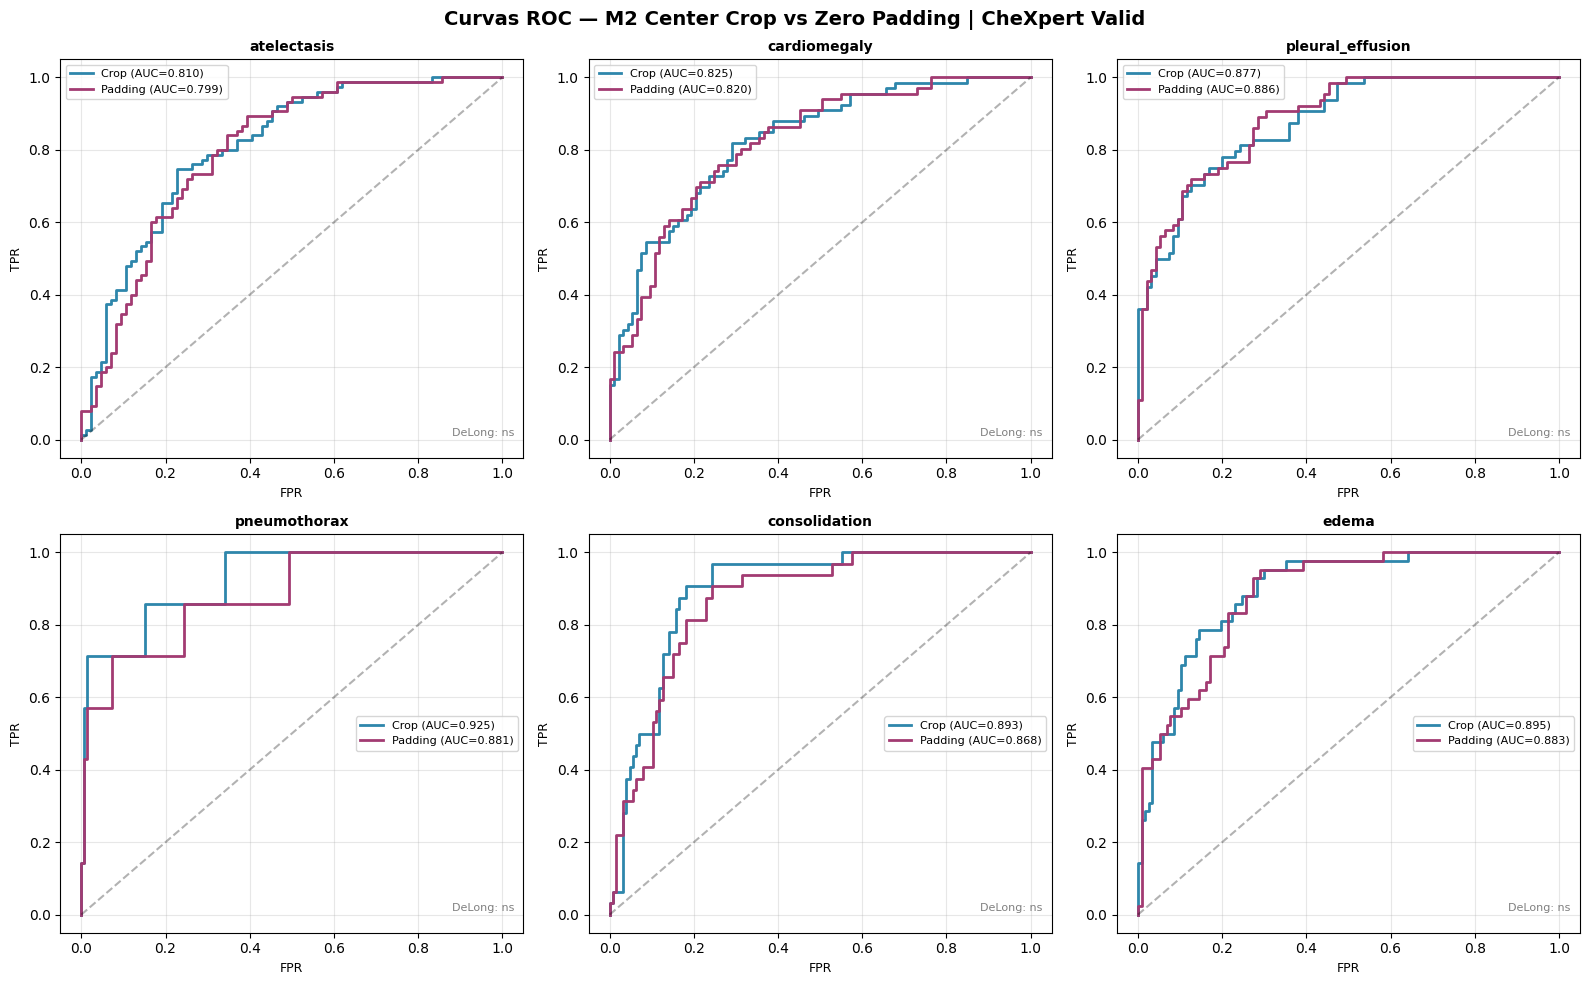

ROC curves salvas.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas ROC — M2 Center Crop vs Zero Padding | CheXpert Valid', fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = {'Crop':'#2E86AB', 'Padding':'#A23B72'}

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        continue

    for model_name, yp, color in [('Crop',y_pred_crop[:,i],'#2E86AB'),
                                   ('Padding',y_pred_pad[:,i],'#A23B72')]:
        fpr, tpr, _ = roc_curve(yt, yp)
        auc = roc_auc_score(yt, yp)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC={auc:.3f})')

    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_xlabel('FPR', fontsize=9)
    ax.set_ylabel('TPR', fontsize=9)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # Mark significance
    if lbl in delong_results:
        sig = delong_results[lbl]['sig']
        ax.text(0.98, 0.05, f'DeLong: {sig}', ha='right', va='bottom',
                fontsize=8, transform=ax.transAxes,
                color='darkgreen' if sig != 'ns' else 'gray')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves salvas.')

## SEÇÃO 6 — Curvas Precision-Recall

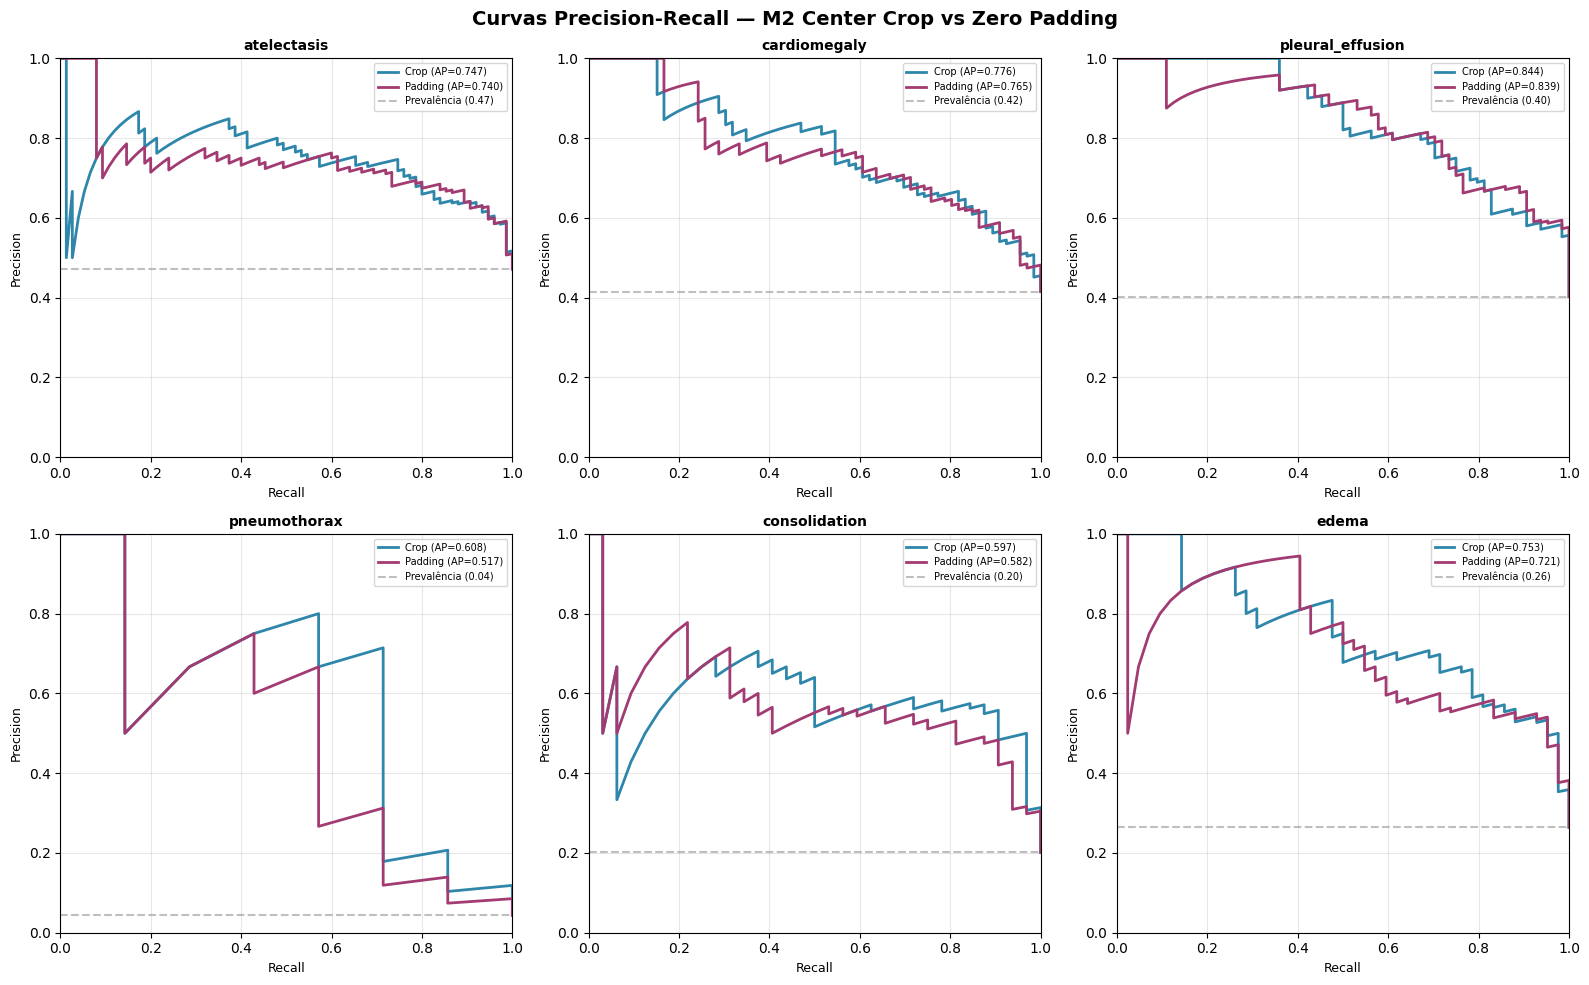

PR curves salvas.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas Precision-Recall — M2 Center Crop vs Zero Padding', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    prevalence = yt.mean()

    for model_name, yp, color in [('Crop',y_pred_crop[:,i],'#2E86AB'),
                                   ('Padding',y_pred_pad[:,i],'#A23B72')]:
        prec, rec, _ = precision_recall_curve(yt, yp)
        auprc = average_precision_score(yt, yp)
        ax.plot(rec, prec, color=color, lw=2, label=f'{model_name} (AP={auprc:.3f})')

    ax.axhline(y=prevalence, color='gray', linestyle='--', alpha=0.5, label=f'Prevalência ({prevalence:.2f})')
    ax.set_xlabel('Recall', fontsize=9)
    ax.set_ylabel('Precision', fontsize=9)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pr_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('PR curves salvas.')

## SEÇÃO 7 — Comparativo Visual de Métricas

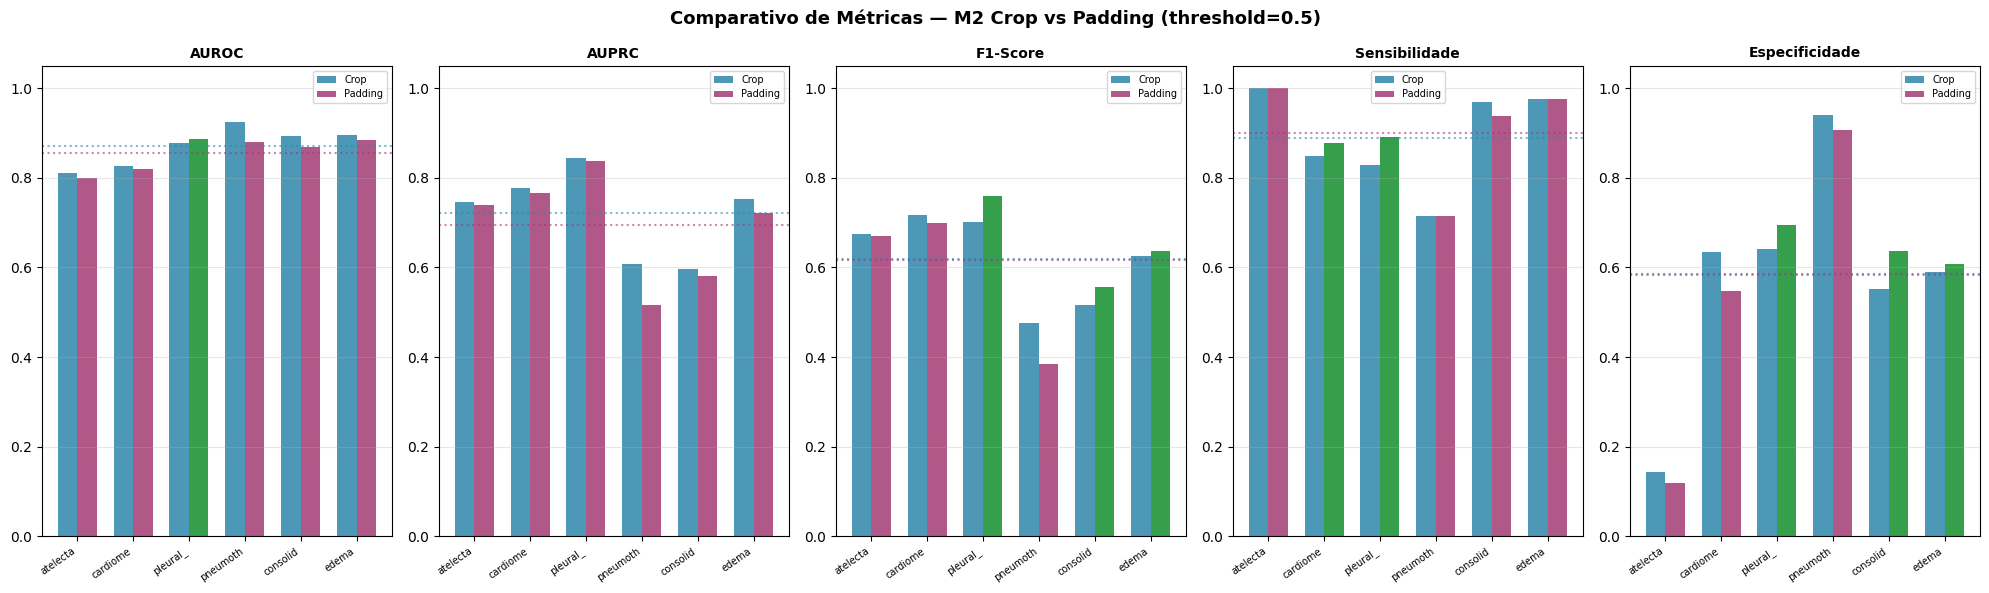

Verde = label onde Padding vence | Linhas pontilhadas = macro de cada modelo


In [11]:
metrics_list = ['auroc','auprc','f1','sensitivity','specificity']
metric_labels = ['AUROC','AUPRC','F1-Score','Sensibilidade','Especificidade']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(20, 6))
fig.suptitle('Comparativo de Métricas — M2 Crop vs Padding (threshold=0.5)', fontsize=13, fontweight='bold')

x = np.arange(len(LABELS))
width = 0.35

for ax, metric, mlbl in zip(axes, metrics_list, metric_labels):
    vals_crop = [metrics_crop[lbl][metric] or 0 for lbl in LABELS]
    vals_pad  = [metrics_pad[lbl][metric]  or 0 for lbl in LABELS]

    bars1 = ax.bar(x - width/2, vals_crop, width, label='Crop',    color='#2E86AB', alpha=0.85)
    bars2 = ax.bar(x + width/2, vals_pad,  width, label='Padding', color='#A23B72', alpha=0.85)

    # Highlight Padding winner
    for j, (vc, vp) in enumerate(zip(vals_crop, vals_pad)):
        if vp > vc:
            ax.bar(j + width/2, vp, width, color='#28A745', alpha=0.9)

    ax.set_title(mlbl, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:8] for l in LABELS], rotation=35, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    # Macro line
    mc = metrics_crop['MACRO'][metric] or 0
    mp = metrics_pad['MACRO'][metric]  or 0
    ax.axhline(y=mc, color='#2E86AB', linestyle=':', alpha=0.6)
    ax.axhline(y=mp, color='#A23B72', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/metrics_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verde = label onde Padding vence | Linhas pontilhadas = macro de cada modelo')

## SEÇÃO 8 — Grad-CAM: Visualização das Ativações

In [17]:
def get_gradcam(model, img_tensor, class_idx, last_conv_layer_name=None):
    """Gera heatmap Grad-CAM para uma imagem e classe."""
    if last_conv_layer_name is None:
        # Busca pelo nome — Xception termina em 'block14_sepconv2_act'
        candidates = ['block14_sepconv2_act', 'block14_sepconv2_bn',
                      'block14_sepconv1_act', 'block13_sepconv2_act']
        for name in candidates:
            try:
                model.get_layer(name)
                last_conv_layer_name = name
                break
            except ValueError:
                continue

        # Fallback: percorre layers buscando output 4D que não seja Dense
        if last_conv_layer_name is None:
            for layer in reversed(model.layers):
                if (hasattr(layer, 'output_shape') and
                    isinstance(layer.output_shape, tuple) and
                    len(layer.output_shape) == 4 and
                    'dense' not in layer.name.lower() and
                    'dropout' not in layer.name.lower()):
                    last_conv_layer_name = layer.name
                    break

    if last_conv_layer_name is None:
        raise ValueError('Nenhuma camada conv encontrada no modelo')

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_batch = tf.expand_dims(img_tensor, 0)
        conv_outputs, predictions = grad_model(img_batch)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy(), float(predictions[0, class_idx])

## SEÇÃO 9 — Exemplos de Inferência Individual

=== Exemplo 1 — Pneumothorax positivo ===


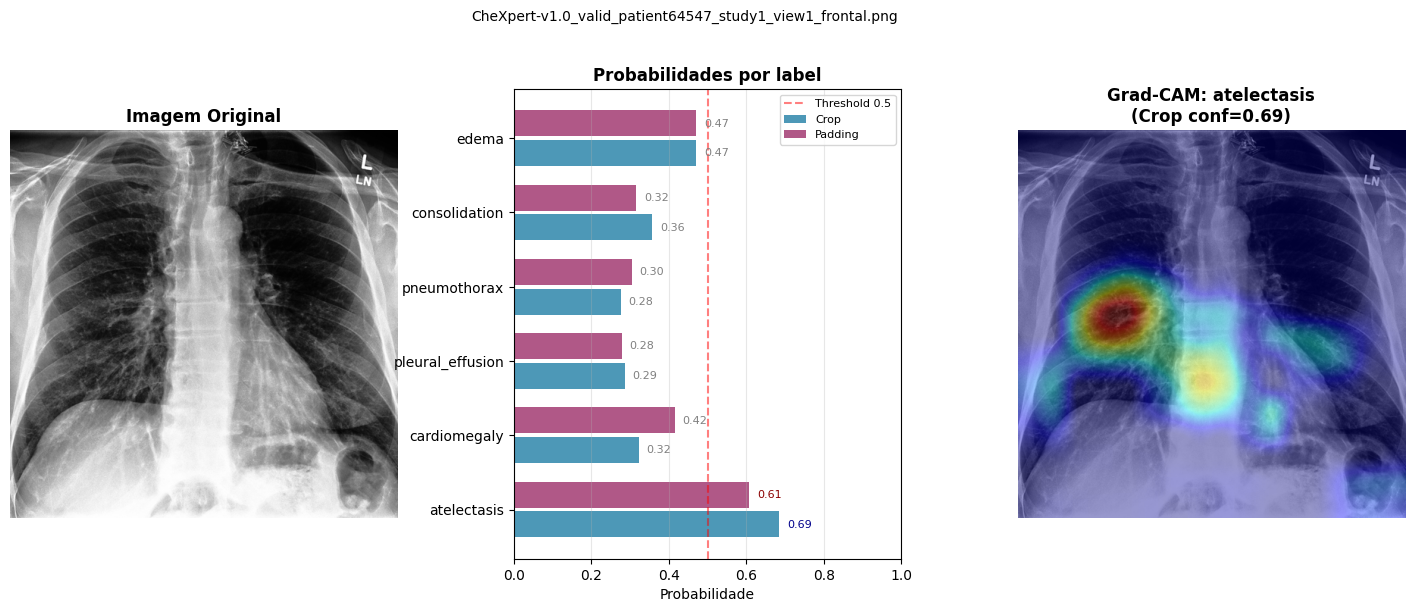


Resultado:
  Label                      Crop  Padding    Delta    Decisao Crop
  -----------------------------------------------------------------
  atelectasis               0.685    0.608   +0.077        POSITIVO
  cardiomegaly              0.323    0.416   -0.093        negativo
  pleural_effusion          0.287    0.279   +0.008        negativo
  pneumothorax              0.276    0.304   -0.029        negativo
  consolidation             0.358    0.316   +0.042        negativo
  edema                     0.472    0.471   +0.000        negativo


In [18]:
def preprocess_image(img_path):
    """Versão PIL — consistente com make_pred_dataset."""
    img = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0
    img = (img - 0.5056) / 0.2520
    img = np.stack([img, img, img], axis=-1)
    return tf.constant(img, dtype=tf.float32)


def predict_single(img_path, model_crop, model_pad, labels, show_gradcam=True):
    """Faz predição em uma imagem com ambos os modelos."""
    img_tensor = preprocess_image(img_path)

    pred_crop = model_crop(tf.expand_dims(img_tensor, 0), training=False).numpy()[0]
    pred_pad  = model_pad(tf.expand_dims(img_tensor, 0),  training=False).numpy()[0]

    n_labels = len(labels)
    ncols = 3 if show_gradcam else 1
    fig = plt.figure(figsize=(18 if show_gradcam else 8, 4 + n_labels * 0.35))
    gs  = gridspec.GridSpec(1, ncols, figure=fig, wspace=0.3)

    ax_img = fig.add_subplot(gs[0, 0])
    raw = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    ax_img.imshow(np.array(raw), cmap='gray')
    ax_img.set_title('Imagem Original', fontweight='bold')
    ax_img.axis('off')

    ax_bar = fig.add_subplot(gs[0, 1] if show_gradcam else gs[0, 0])
    y_pos  = np.arange(n_labels)
    ax_bar.barh(y_pos - 0.2, pred_crop, 0.35, label='Crop',    color='#2E86AB', alpha=0.85)
    ax_bar.barh(y_pos + 0.2, pred_pad,  0.35, label='Padding', color='#A23B72', alpha=0.85)
    ax_bar.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold 0.5')
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(labels, fontsize=10)
    ax_bar.set_xlabel('Probabilidade', fontsize=10)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title('Probabilidades por label', fontweight='bold')
    ax_bar.legend(fontsize=8)
    ax_bar.grid(axis='x', alpha=0.3)

    for j, (pc, pp) in enumerate(zip(pred_crop, pred_pad)):
        color_c = 'darkblue' if pc > 0.5 else 'gray'
        color_p = 'darkred'  if pp > 0.5 else 'gray'
        ax_bar.text(min(pc+0.02, 0.98), j-0.2, f'{pc:.2f}', va='center', fontsize=8, color=color_c)
        ax_bar.text(min(pp+0.02, 0.98), j+0.2, f'{pp:.2f}', va='center', fontsize=8, color=color_p)

    if show_gradcam:
        top_label_idx = int(np.argmax(pred_crop))
        ax_cam = fig.add_subplot(gs[0, 2])
        try:
            heatmap, conf = get_gradcam(model_crop, img_tensor, top_label_idx)
            overlay, _ = overlay_gradcam(img_path, heatmap)
            ax_cam.imshow(overlay)
            ax_cam.set_title(
                f'Grad-CAM: {labels[top_label_idx]}\n(Crop conf={conf:.2f})',
                fontweight='bold'
            )
        except Exception as e:
            ax_cam.text(
                0.5, 0.5,
                f'Grad-CAM\nindisponivel\n{str(e)[:30]}',
                ha='center', va='center', fontsize=8
            )
        ax_cam.axis('off')

    fig.suptitle(f'{img_path.split("/")[-1]}', fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

    print('\nResultado:')
    print(f'  {"Label":<22} {"Crop":>8} {"Padding":>8} {"Delta":>8} {"Decisao Crop":>15}')
    print('  ' + '-'*65)
    for j, lbl in enumerate(labels):
        delta = pred_crop[j] - pred_pad[j]
        decision = 'POSITIVO' if pred_crop[j] >= 0.5 else 'negativo'
        print(f'  {lbl:<22} {pred_crop[j]:>8.3f} {pred_pad[j]:>8.3f} {delta:>+8.3f} {decision:>15}')

    return pred_crop, pred_pad


# ── Exemplos ──────────────────────────────────────────────────────────────────
pneumo_imgs = df_valid_crop[df_valid_crop['pneumothorax'] == 1]['img_path'].head(3).tolist()
if pneumo_imgs:
    print('=== Exemplo 1 — Pneumothorax positivo ===')
    p_c, p_p = predict_single(pneumo_imgs[0], model_crop, model_pad, LABELS)

=== Exemplo 2 — Pleural Effusion positivo ===


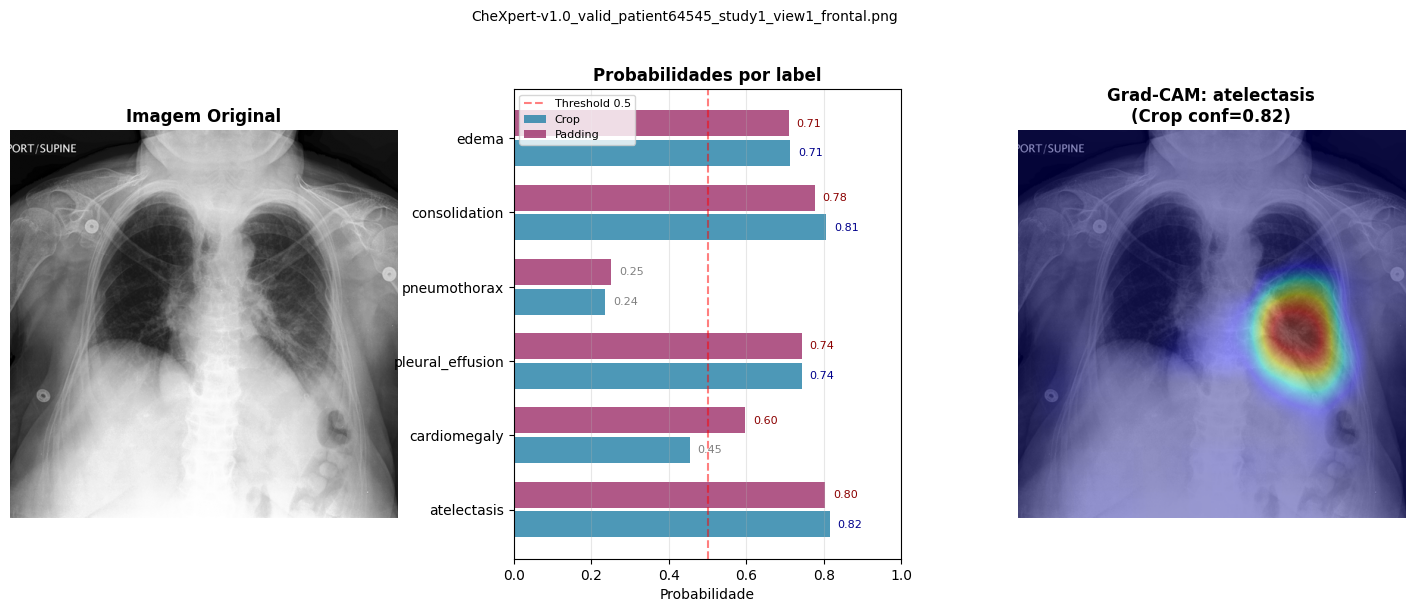


Resultado:
  Label                      Crop  Padding    Delta    Decisao Crop
  -----------------------------------------------------------------
  atelectasis               0.815    0.803   +0.012        POSITIVO
  cardiomegaly              0.454    0.597   -0.143        negativo
  pleural_effusion          0.743    0.744   -0.001        POSITIVO
  pneumothorax              0.236    0.251   -0.015        negativo
  consolidation             0.806    0.777   +0.029        POSITIVO
  edema                     0.714    0.710   +0.003        POSITIVO


In [19]:
# ── Exemplo 2: Imagem com Pleural Effusion positiva ──────────────────────────
effusion_imgs = df_valid_crop[df_valid_crop['pleural_effusion'] == 1]['img_path'].head(3).tolist()
if effusion_imgs:
    print('=== Exemplo 2 — Pleural Effusion positivo ===')
    p_c, p_p = predict_single(effusion_imgs[0], model_crop, model_pad, LABELS)

=== Exemplo 3 — Múltiplas patologias ===


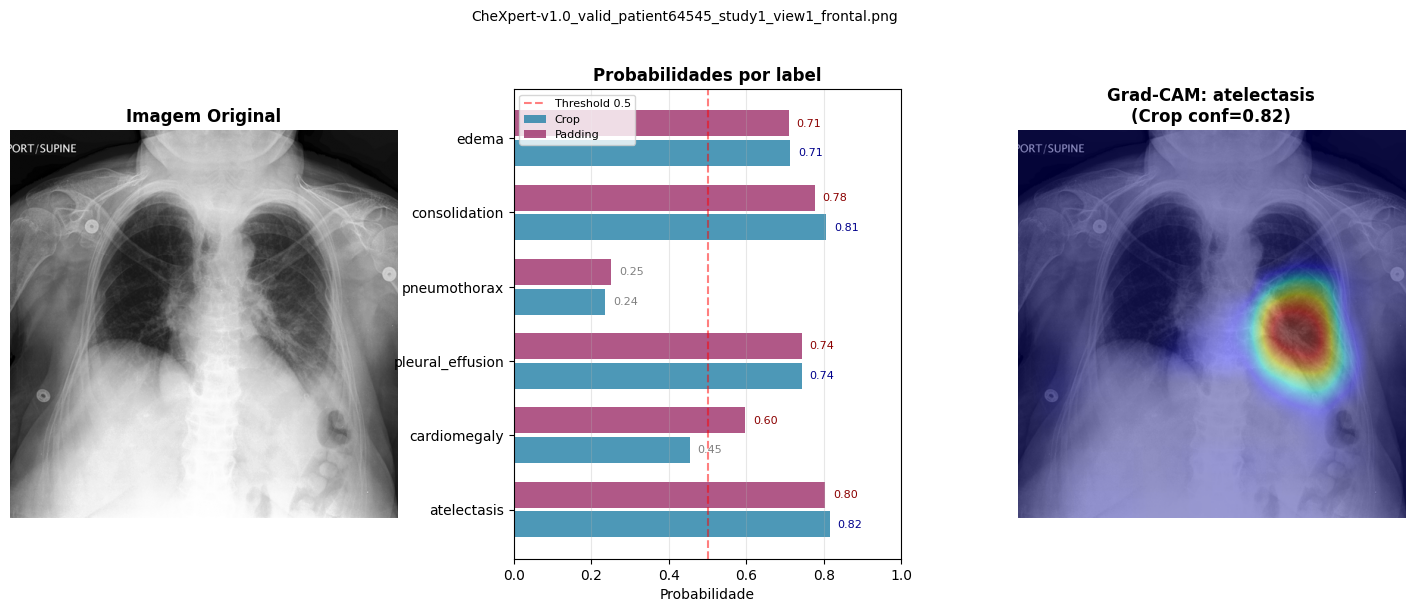


Resultado:
  Label                      Crop  Padding    Delta    Decisao Crop
  -----------------------------------------------------------------
  atelectasis               0.815    0.803   +0.012        POSITIVO
  cardiomegaly              0.454    0.597   -0.143        negativo
  pleural_effusion          0.743    0.744   -0.001        POSITIVO
  pneumothorax              0.236    0.251   -0.015        negativo
  consolidation             0.806    0.777   +0.029        POSITIVO
  edema                     0.714    0.710   +0.003        POSITIVO


In [20]:
# ── Exemplo 3: Imagem com múltiplas patologias ───────────────────────────────
df_valid_crop['n_pos'] = df_valid_crop[LABELS].sum(axis=1)
multi_imgs = df_valid_crop[df_valid_crop['n_pos'] >= 2]['img_path'].head(3).tolist()
if multi_imgs:
    print('=== Exemplo 3 — Múltiplas patologias ===')
    p_c, p_p = predict_single(multi_imgs[0], model_crop, model_pad, LABELS)

## SEÇÃO 10 — Uso em Produção (Função Reutilizável)

In [22]:
def classify_cxr(img_path, model=None, preprocessing='crop',
                  threshold=0.5, verbose=True):
    """
    Classifica uma radiografia de tórax.

    Parâmetros:
    -----------
    img_path      : str — caminho para PNG 512×512
    model         : tf.keras.Model — modelo M2 (padrão: model_crop)
    preprocessing : 'crop' ou 'pad' — qual preprocessing foi usado no treino
    threshold     : float — limiar de classificação binária (padrão 0.5)
    verbose       : bool — imprime resultado formatado

    Retorna:
    --------
    dict com probabilidades e classificações binárias por label
    """
    if model is None:
        model = model_crop

    img_tensor = preprocess_image(img_path)
    probs = model(tf.expand_dims(img_tensor, 0), training=False).numpy()[0]

    result = {
        'img_path'   : img_path,
        'model'      : 'M2_Crop_UIgnore' if model is model_crop else 'M2_Pad_UIgnore',
        'threshold'  : threshold,
        'predictions': {}
    }
    positives = []
    for i, lbl in enumerate(LABELS):
        prob = float(probs[i])
        is_positive = prob >= threshold
        result['predictions'][lbl] = {'probability': prob, 'positive': is_positive}
        if is_positive:
            positives.append((lbl, prob))

    result['summary'] = {
        'n_positive'    : len(positives),
        'findings'      : sorted(positives, key=lambda x: -x[1]),
        'macro_prob'    : float(np.mean(probs)),
        'no_finding'    : len(positives) == 0,
    }

    if verbose:
        print(f'\n Classificação CXR')
        print(f'  Imagem  : {img_path.split("/")[-1]}')
        print(f'  Modelo  : {result["model"]}')
        print(f'  Threshold: {threshold}')
        print(f'\n  {"Label":<22} {"Prob":>8} {"Status":>12}')
        print('  ' + '-'*45)
        for lbl, d in result['predictions'].items():
            status = '✅ POSITIVO' if d['positive'] else '  negativo'
            bar = '█' * int(d['probability'] * 20)
            print(f'  {lbl:<22} {d["probability"]:>8.3f} {status:>12}  {bar}')
        print('  ' + '-'*45)
        if result['summary']['no_finding']:
            print('  Resultado: Sem achados significativos')
        else:
            print(f'  Achados  : {len(positives)} patologia(s) detectada(s)')
            for lbl, prob in result['summary']['findings']:
                print(f'             → {lbl} ({prob:.1%})')

    return result


# ── Demonstração de uso ────────────────────────────────────────────────────────
print('=== USO EM PRODUÇÃO ===')
sample_img = df_valid_crop['img_path'].iloc[0]

# Usando modelo Crop (recomendado)
result = classify_cxr(sample_img, model=model_crop, preprocessing='crop')

# Acesso programático
print(f'\nAcesso programático:')
print(f'  Pneumothorax prob  : {result["predictions"]["pneumothorax"]["probability"]:.3f}')
print(f'  É positivo?        : {result["predictions"]["pneumothorax"]["positive"]}')
print(f'  Achados positivos  : {[f for f,_ in result["summary"]["findings"]]}')

=== USO EM PRODUÇÃO ===

 Classificação CXR
  Imagem  : CheXpert-v1.0_valid_patient64541_study1_view1_frontal.png
  Modelo  : M2_Crop_UIgnore
  Threshold: 0.5

  Label                      Prob       Status
  ---------------------------------------------
  atelectasis               0.568   ✅ POSITIVO  ███████████
  cardiomegaly              0.382     negativo  ███████
  pleural_effusion          0.144     negativo  ██
  pneumothorax              0.199     negativo  ███
  consolidation             0.166     negativo  ███
  edema                     0.269     negativo  █████
  ---------------------------------------------
  Achados  : 1 patologia(s) detectada(s)
             → atelectasis (56.8%)

Acesso programático:
  Pneumothorax prob  : 0.199
  É positivo?        : False
  Achados positivos  : ['atelectasis']


## SEÇÃO 11 — Resumo Final e Decisão

In [23]:
print('='*65)
print('RESUMO COMPARATIVO — M2 Center Crop vs Zero Padding')
print('='*65)

print(f'\n{"Label":<22} {"Crop":>8} {"Padding":>8} {"Δ":>8} {"DeLong":>8}')
print('-'*55)
crop_wins = pad_wins = 0
for lbl in LABELS:
    auc_c = metrics_crop[lbl]['auroc']
    auc_p = metrics_pad[lbl]['auroc']
    if auc_c is None: continue
    delta = auc_c - auc_p
    sig   = delong_results.get(lbl,{}).get('sig','—')
    winner= '← Crop' if delta > 0 else '← Pad '
    if delta > 0: crop_wins += 1
    else: pad_wins += 1
    print(f'{lbl:<22} {auc_c:>8.4f} {auc_p:>8.4f} {delta:>+8.4f}  {sig:>5}  {winner}')
print('-'*55)
mc = metrics_crop['MACRO']['auroc']
mp = metrics_pad['MACRO']['auroc']
print(f'{"MACRO":<22} {mc:>8.4f} {mp:>8.4f} {mc-mp:>+8.4f}')
print()
print(f'  Crop vence    : {crop_wins}/6 labels')
print(f'  Padding vence : {pad_wins}/6 labels')
print()
print(f'  DECISÃO: CENTER CROP para M3 e M4')
print(f'  Único benefício do Padding: Pleural Effusion (+{metrics_pad["pleural_effusion"]["auroc"]-metrics_crop["pleural_effusion"]["auroc"]:+.4f})')
print(f'  Maior perda do Padding    : Pneumothorax ({metrics_crop["pneumothorax"]["auroc"]-metrics_pad["pneumothorax"]["auroc"]:+.4f})')
print()
print(f'Modelos recomendados para M3:')
print(f'  m2_crop_final.keras → ponto de partida do M3 U-Ones')
print('='*65)

RESUMO COMPARATIVO — M2 Center Crop vs Zero Padding

Label                      Crop  Padding        Δ   DeLong
-------------------------------------------------------
atelectasis              0.8103   0.7992  +0.0111     ns  ← Crop
cardiomegaly             0.8254   0.8196  +0.0057     ns  ← Crop
pleural_effusion         0.8773   0.8857  -0.0084     ns  ← Pad 
pneumothorax             0.9248   0.8806  +0.0442     ns  ← Crop
consolidation            0.8932   0.8684  +0.0249     ns  ← Crop
edema                    0.8948   0.8834  +0.0114     ns  ← Crop
-------------------------------------------------------
MACRO                    0.8710   0.8562  +0.0148

  Crop vence    : 5/6 labels
  Padding vence : 1/6 labels

  DECISÃO: CENTER CROP para M3 e M4
  Único benefício do Padding: Pleural Effusion (++0.0084)
  Maior perda do Padding    : Pneumothorax (+0.0442)

Modelos recomendados para M3:
  m2_crop_final.keras → ponto de partida do M3 U-Ones


## SEÇÃO 12 — Relatório

In [25]:
# ── SEÇÃO 12 — Relatório Automático via Claude API ──────────────────────────
!pip install -q anthropic

import anthropic
import time

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

# ── Garante que métricas estão em memória ─────────────────────────────────────
if 'metrics_crop' not in dir() or 'metrics_pad' not in dir():
    with open(f'{OUT_DIR}/metrics_comparison.json') as f:
        comp = json.load(f)
    metrics_crop = comp['crop']
    metrics_pad  = comp['pad']

if 'delong_results' not in dir():
    delong_results = {}

# ── Carrega resultados M1 para comparação tripla ──────────────────────────────
try:
    with open(f'{BASE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json') as f:
        m1_res = json.load(f)
    m1_macro     = m1_res['macro_auroc']
    m1_per_label = m1_res['per_label_auroc']
except Exception:
    m1_macro = None; m1_per_label = {}

# ── Monta contexto completo ───────────────────────────────────────────────────
metric_names = ['auroc', 'auprc', 'f1', 'sensitivity', 'specificity', 'brier']

label_table_lines = []
for lbl in LABELS:
    mc = metrics_crop.get(lbl, {})
    mp = metrics_pad.get(lbl, {})
    m1_auc = m1_per_label.get(lbl, None)
    delta_cp  = (mc.get('auroc',0) - mp.get('auroc',0))
    delta_m1c = (mc.get('auroc',0) - m1_auc) if m1_auc else None
    delong_sig = delong_results.get(lbl, {}).get('sig', 'N/A')
    delong_p   = delong_results.get(lbl, {}).get('p',   None)
    line = (
        f"  {lbl:<22}: "
        f"M1={f'{m1_auc:.4f}' if m1_auc else 'N/A'} | "
        f"Crop AUROC={mc.get('auroc',0):.4f} | "
        f"Pad AUROC={mp.get('auroc',0):.4f} | "
        f"ΔCrop→Pad={delta_cp:+.4f} | "
        f"AUPRC Crop={mc.get('auprc',0):.4f} | AUPRC Pad={mp.get('auprc',0):.4f} | "
        f"F1 Crop={mc.get('f1',0):.4f} | F1 Pad={mp.get('f1',0):.4f} | "
        f"Sens Crop={mc.get('sensitivity',0):.4f} | Sens Pad={mp.get('sensitivity',0):.4f} | "
        f"Spec Crop={mc.get('specificity',0):.4f} | Spec Pad={mp.get('specificity',0):.4f} | "
        f"DeLong={delong_sig} (p={f'{delong_p:.4f}' if delong_p else 'N/A'})"
    )
    label_table_lines.append(line)
label_table = '\n'.join(label_table_lines)

macro_c = metrics_crop.get('MACRO', {})
macro_p = metrics_pad.get('MACRO', {})

context = f"""
EXPERIMENTO: Avaliação Comparativa M2 — Center Crop vs Zero Padding
OBJETIVO: Determinar qual estratégia de preprocessing preserva mais informação diagnóstica
          para classificação multi-label de radiografias de tórax (6 patologias)

CONFIGURAÇÃO DOS MODELOS:
  Backbone      : Xception 512×512 (ImageNet → NIH → CheXpert)
  Política -1   : U-Ignore (labels incertos descartados da loss)
  Loss          : Focal Loss γ=2.0 α=0.25 + pesos por label
  Dataset valid : Stanford CheXpert — 159 imagens
  Labels        : atelectasis, cardiomegaly, pleural_effusion, pneumothorax, consolidation, edema

PREPROCESSING:
  Center Crop : Recorta 2320×2320 a partir do centro → resize 512×512 (descarta ~254px por lado)
  Zero Padding: Adiciona bordas pretas até 2828×2828 → resize 512×512 (~46px pretos por lado, ~9% área)

RESULTADOS POR LABEL — MÉTRICAS COMPLETAS:
{label_table}

MACRO (média das 6 patologias):
  Crop  : AUROC={macro_c.get('auroc',0):.4f} | AUPRC={macro_c.get('auprc',0):.4f} | F1={macro_c.get('f1',0):.4f} | Sens={macro_c.get('sensitivity',0):.4f} | Spec={macro_c.get('specificity',0):.4f} | Brier={macro_c.get('brier',0):.4f}
  Pad   : AUROC={macro_p.get('auroc',0):.4f} | AUPRC={macro_p.get('auprc',0):.4f} | F1={macro_p.get('f1',0):.4f} | Sens={macro_p.get('sensitivity',0):.4f} | Spec={macro_p.get('specificity',0):.4f} | Brier={macro_p.get('brier',0):.4f}
  Δ Crop→Pad: AUROC={macro_c.get('auroc',0)-macro_p.get('auroc',0):+.4f} | AUPRC={macro_c.get('auprc',0)-macro_p.get('auprc',0):+.4f} | F1={macro_c.get('f1',0)-macro_p.get('f1',0):+.4f}

BASELINE M1 (NIH — sem fine-tuning CheXpert):
  Macro-AUROC: {f'{m1_macro:.4f}' if m1_macro else 'N/A'}
  Ganho M1→Crop  : {f'{macro_c.get("auroc",0)-m1_macro:+.4f}' if m1_macro else 'N/A'}
  Ganho M1→Pad   : {f'{macro_p.get("auroc",0)-m1_macro:+.4f}' if m1_macro else 'N/A'}

TESTE ESTATÍSTICO DELONG (comparação de AUROCs, n=159):
  Labels com diferença significativa (p<0.05): {[l for l,d in delong_results.items() if d.get('sig','ns') not in ['ns','N/A']]}
  Nota: n=159 limita o poder estatístico — diferenças clinicamente relevantes podem não atingir significância

CONTEXTO DO ABLATION:
  Variável isolada M1→M2 : impacto do domain transfer NIH→CheXpert
  Variável isolada Crop→Pad: impacto exclusivo do preprocessing
  Decisão desta seção informa diretamente M3 e M4
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica especializado em análise de radiografias de tórax.

Abaixo estão os resultados completos da avaliação comparativa entre M2 Center Crop e M2 Zero Padding, parte do ablation study de classificação multi-label de CXR com Xception 512×512.

{context}

Produza um relatório técnico estruturado cobrindo:

1. **Resumo executivo**: qual preprocessing venceu, por quanto, e o que isso significa para o ablation
2. **Análise por label — AUROC**: quais labels foram mais/menos sensíveis ao preprocessing e por quê anatomicamente
3. **Além do AUROC — F1, Sensibilidade e Especificidade**: o modelo Crop é superior também nas métricas operacionais (threshold=0.5)? Há trade-offs entre Sens/Spec entre os dois modelos?
4. **AUPRC — análise de precisão-recall**: dado o desbalanceamento do valid set, o AUPRC confirma as conclusões do AUROC?
5. **Teste DeLong**: as diferenças são estatisticamente significativas? Como interpretar os resultados dado n=159?
6. **Hipótese anatômica para os resultados**: explique o mecanismo pelo qual o Center Crop supera o Padding para Pneumothorax e o Padding supera para Pleural Effusion
7. **Impacto do domain transfer (M1→M2)**: o ganho sobre o M1 foi consistente entre os dois preprocessings?
8. **Recomendação definitiva**: qual modelo deve ser usado como ponto de partida para M3, com justificativa técnica
9. **Limitações e riscos**: o que os resultados NÃO podem garantir dado o tamanho do valid set

Seja direto, técnico e cite os números exatos. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()

message = client.messages.create(
    model='claude-sonnet-4-6',
    max_tokens=8192,
    messages=[{'role': 'user', 'content': prompt}]
)

relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} tokens in | {message.usage.output_tokens} tokens out')

print('\n' + '='*65)
print('RELATÓRIO COMPARATIVO M2 — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/comparativo_crop_padding_relatorio_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')

Enviando para Claude API...
Resposta em 134.1s | 2151 tokens in | 7214 tokens out

RELATÓRIO COMPARATIVO M2 — Claude Sonnet
# Relatório Técnico: Ablation Study M2 — Center Crop vs Zero Padding
### Classificação Multi-Label CXR | Xception 512×512 | CheXpert Validation (n=159)

---

## 1. Resumo Executivo

**O Center Crop venceu em 5 das 6 patologias por AUROC**, com margem macro de **ΔAUROC = +0.0148** (Crop: 0.8710 vs Pad: 0.8562) e **ΔAUPRC = +0.0268** (0.7208 vs 0.6940). A exceção foi Pleural Effusion, onde o Zero Padding superou por −0.0084 AUROC — a única inversão do padrão.

Para o ablation study, este resultado tem implicação direta: **a variável preprocessing, isolada de todas as outras**, favorece o Center Crop como estratégia de entrada para M3 e M4. O ganho não é trivial — o intervalo de +0.0148 macro-AUROC representa aproximadamente 14,6% do ganho total obtido pelo domain transfer M1→M2 (que foi +0.1013 para Crop). Isso significa que a escolha de preprocessing responde por u